# 12. CNN Visualization

This notebook explores what a convolutional neural network responds to by visualizing filters, feature maps, intermediate activations, input saliency, and Grad-CAM.

All example images come from the CIFAR-10 dataset already stored in this project at data/cifar-10-batches-py. Dataset loading uses download=False. The notebook uses the fine-tuned local CIFAR-10 ResNet checkpoint from notebook 10 when available; otherwise it uses TorchVision's ImageNet-pretrained ResNet-18 weights.

## 1. What can CNN visualizations tell us?

Visualizations provide clues about patterns associated with a model's response. They are useful for exploration, debugging, and communication, but they do not by themselves prove that a model reasons as a person would.

- **Filters:** learned convolution kernels; the first-layer kernels can be displayed directly.
- **Feature maps / intermediate activations:** spatial responses produced at selected layers for one input.
- **Saliency:** input-pixel sensitivity of a chosen class score.
- **Grad-CAM:** a coarse localization map formed from gradients and feature maps of a deeper convolutional layer.

## 2. A typical feature hierarchy

- **Early layers → edges and simple patterns:** first layers often respond to oriented edges, color contrasts, and simple textures.
- **Middle layers → textures and shapes:** intermediate blocks combine simple responses into motifs, texture fragments, and parts.
- **Deeper layers → higher-level patterns:** later layers can respond to combinations associated with larger object parts or class-relevant patterns.

This is a useful general interpretation, not a strict rule. The exact response depends on the architecture, learned weights, input, and data domain.

Device: cpu
Image source: local CIFAR-10 test set (10000 images)
Model: Local CIFAR-10 fine-tuned checkpoint from notebook 10
Dataset label: cat
Model prediction: cat


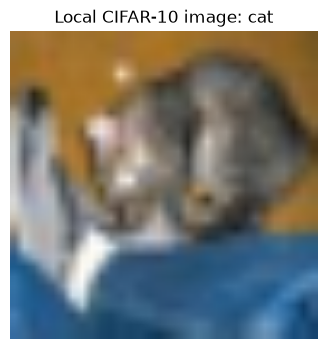

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms

DATA_ROOT = Path("data")
CIFAR_DIR = DATA_ROOT / "cifar-10-batches-py"
CHECKPOINT_PATH = Path("artifacts") / "resnet18_cifar10_finetuned.pth"
IMAGE_SIZE = 224
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not CIFAR_DIR.is_dir():
    raise FileNotFoundError(f"Local CIFAR-10 data not found: {CIFAR_DIR.resolve()}")

normalization_mean = (0.485, 0.456, 0.406)
normalization_std = (0.229, 0.224, 0.225)
image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=normalization_mean, std=normalization_std),
])
test_dataset = datasets.CIFAR10(
    root=str(DATA_ROOT), train=False, download=False, transform=image_transform
)
class_names = test_dataset.classes
image_index = 0
input_tensor, true_label = test_dataset[image_index]
input_batch = input_tensor.unsqueeze(0).to(device)
if CHECKPOINT_PATH.is_file():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(class_names))
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True))
    class_labels = class_names
    model_source = "Local CIFAR-10 fine-tuned checkpoint from notebook 10"
else:
    weights = models.ResNet18_Weights.DEFAULT
    model = models.resnet18(weights=weights)
    class_labels = weights.meta["categories"]
    model_source = "TorchVision ImageNet-pretrained ResNet-18"
model = model.to(device).eval()
print(f"Device: {device}")
print(f"Image source: local CIFAR-10 test set ({len(test_dataset)} images)")
print(f"Model: {model_source}")
mean_tensor = torch.tensor(normalization_mean).view(3, 1, 1)
std_tensor = torch.tensor(normalization_std).view(3, 1, 1)
display_image = (input_tensor * std_tensor + mean_tensor).clamp(0, 1).permute(1, 2, 0).numpy()
with torch.inference_mode():
    initial_logits = model(input_batch)
    predicted_index = int(initial_logits.argmax(dim=1).item())
print(f"Dataset label: {class_names[true_label]}")
print(f"Model prediction: {class_labels[predicted_index]}")
plt.figure(figsize=(4, 4))
plt.imshow(display_image)
plt.title(f"Local CIFAR-10 image: {class_names[true_label]}")
plt.axis("off")
plt.show()

## 3. Filter visualization: first convolution

The first convolution's weights can be visualized directly. Each RGB filter is independently scaled for display. These are learned parameters, not feature maps for the selected image.

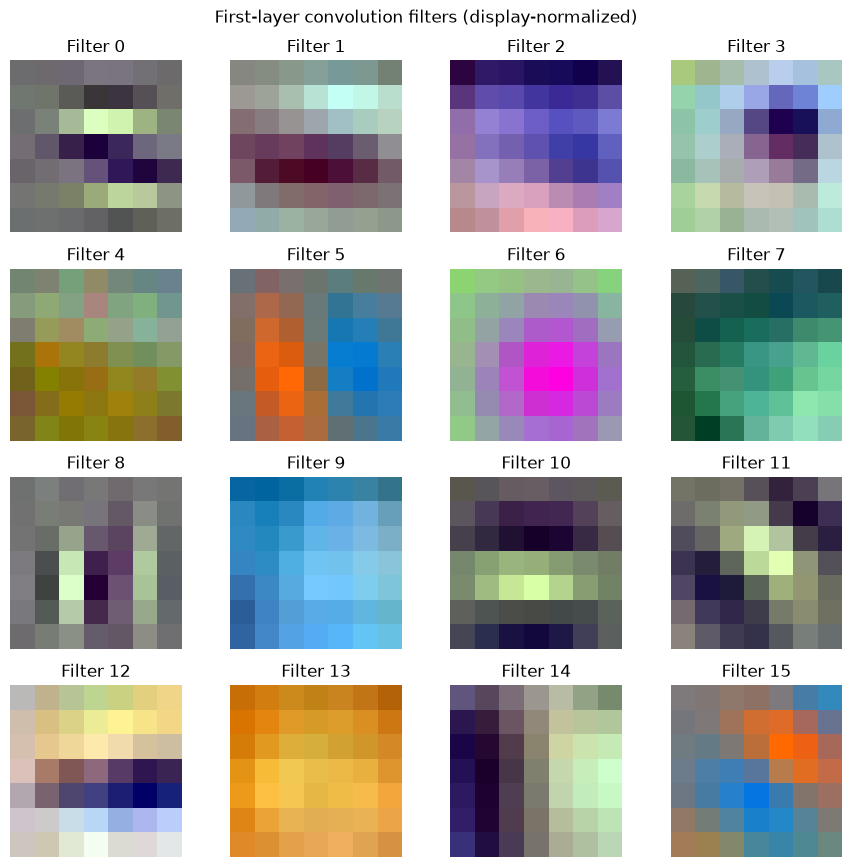

In [2]:
first_conv = model.conv1
filters = first_conv.weight.detach().cpu()
num_filters = min(16, filters.shape[0])
columns = 4
rows = (num_filters + columns - 1) // columns
fig, axes = plt.subplots(rows, columns, figsize=(9, 2.2 * rows))
axes = np.asarray(axes).reshape(-1)
for filter_index, ax in enumerate(axes):
    if filter_index < num_filters:
        kernel = filters[filter_index].permute(1, 2, 0).numpy()
        kernel_min, kernel_max = kernel.min(), kernel.max()
        kernel = (kernel - kernel_min) / (kernel_max - kernel_min + 1e-8)
        ax.imshow(kernel)
        ax.set_title(f"Filter {filter_index}")
    ax.axis("off")
fig.suptitle("First-layer convolution filters (display-normalized)")
fig.tight_layout()
plt.show()

## 4. Feature maps / intermediate activations

We capture outputs from ResNet-18's stem and residual stages. A feature map is one channel of a layer's response to the input. The displayed maps are individually normalized so their spatial structure is visible; colors are relative response strength within each map.

In [3]:
activation_layers = {
    "Early: conv1 (edges / simple patterns)": model.conv1,
    "Middle: layer1 (textures / simple motifs)": model.layer1,
    "Middle: layer2 (textures / shapes)": model.layer2,
    "Deep: layer4 (higher-level patterns)": model.layer4,
}
captured_activations = {}
hook_handles = []
def save_activation(name):
    def hook(_module, _inputs, output):
        captured_activations[name] = output.detach().cpu()
    return hook
for layer_name, layer in activation_layers.items():
    hook_handles.append(layer.register_forward_hook(save_activation(layer_name)))
with torch.inference_mode():
    _ = model(input_batch)
for handle in hook_handles:
    handle.remove()
for layer_name, activation in captured_activations.items():
    print(f"{layer_name}: {tuple(activation.shape)}")

Early: conv1 (edges / simple patterns): (1, 64, 112, 112)
Middle: layer1 (textures / simple motifs): (1, 64, 56, 56)
Middle: layer2 (textures / shapes): (1, 128, 28, 28)
Deep: layer4 (higher-level patterns): (1, 512, 7, 7)


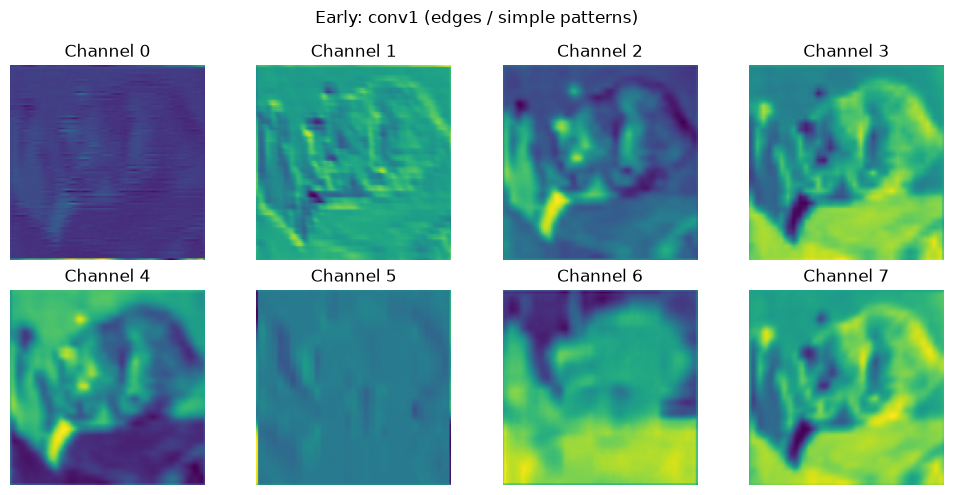

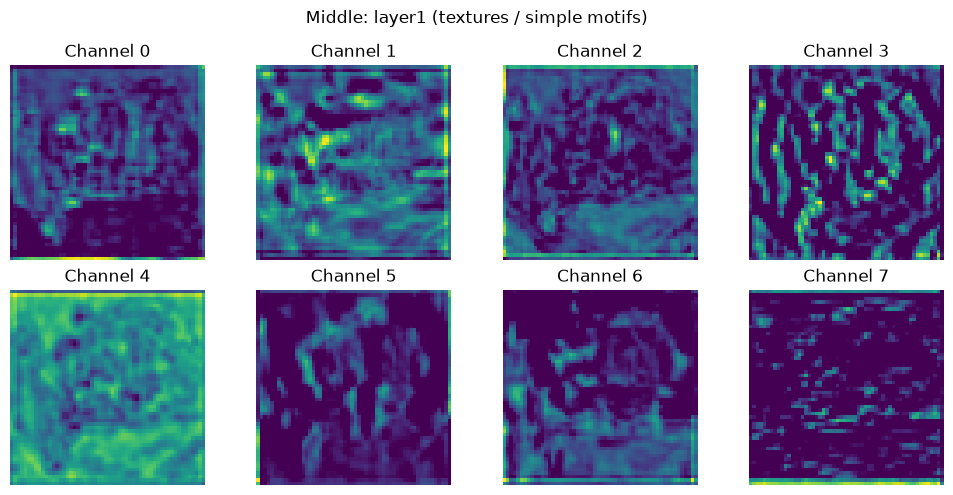

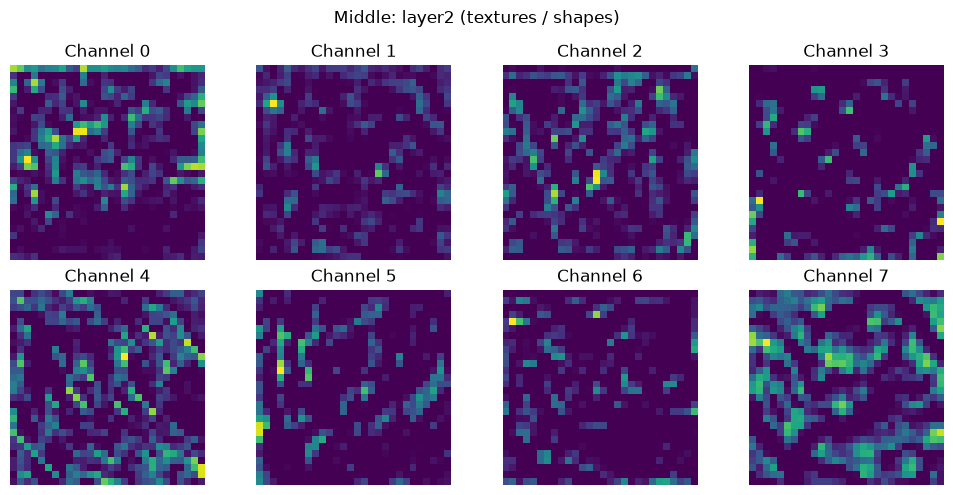

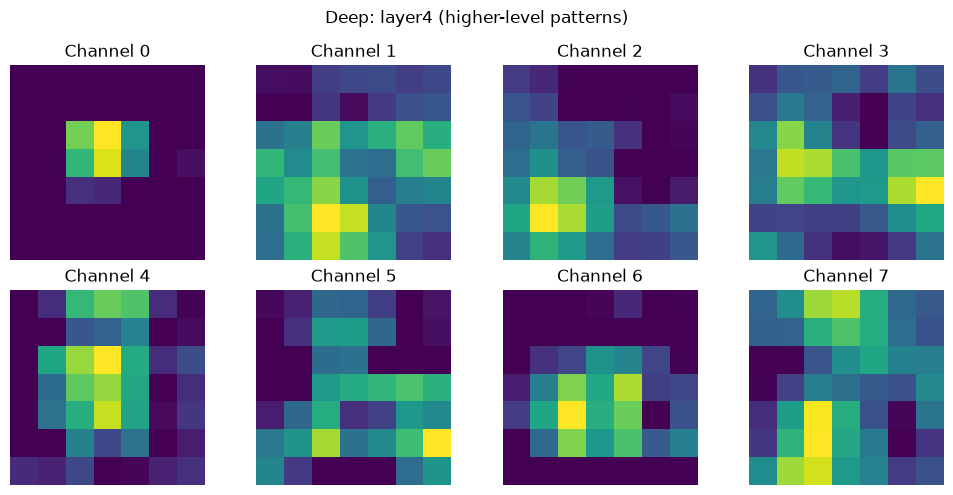

In [4]:
def plot_feature_maps(layer_name, channels=8):
    feature_maps = captured_activations[layer_name][0]
    count = min(channels, feature_maps.shape[0])
    columns = 4
    rows = (count + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(10, 2.5 * rows))
    axes = np.asarray(axes).reshape(-1)
    for channel_index, ax in enumerate(axes):
        if channel_index < count:
            feature_map = feature_maps[channel_index].numpy()
            low, high = feature_map.min(), feature_map.max()
            ax.imshow(feature_map, cmap="viridis", vmin=low, vmax=high if high > low else low + 1e-8)
            ax.set_title(f"Channel {channel_index}")
        ax.axis("off")
    fig.suptitle(layer_name)
    fig.tight_layout()
    plt.show()
for layer_name in activation_layers:
    plot_feature_maps(layer_name, channels=8)

### Interpreting layer visualizations

Compare the spatial resolution printed for each captured tensor. Convolutions and downsampling reduce spatial size while later stages create more channels.

- **Early layers → edges/simple patterns:** expect localized responses to contrast boundaries and simple directions.
- **Middle layers → textures/shapes:** responses combine edges into repeated texture, curves, corners, or object parts.
- **Deeper layers → higher-level patterns:** feature maps can highlight regions useful for class discrimination, but may be spatially coarse.

Do not assign a semantic name to an individual channel without checking many inputs. A channel may respond to several related patterns.

## 5. Saliency maps

A saliency map estimates how sensitive a selected class score is to each input pixel. Here we differentiate the predicted class score with respect to the normalized input, then combine absolute gradients across RGB channels.

Saliency is local sensitivity, not proof of causation. It can be noisy and sensitive to model details.

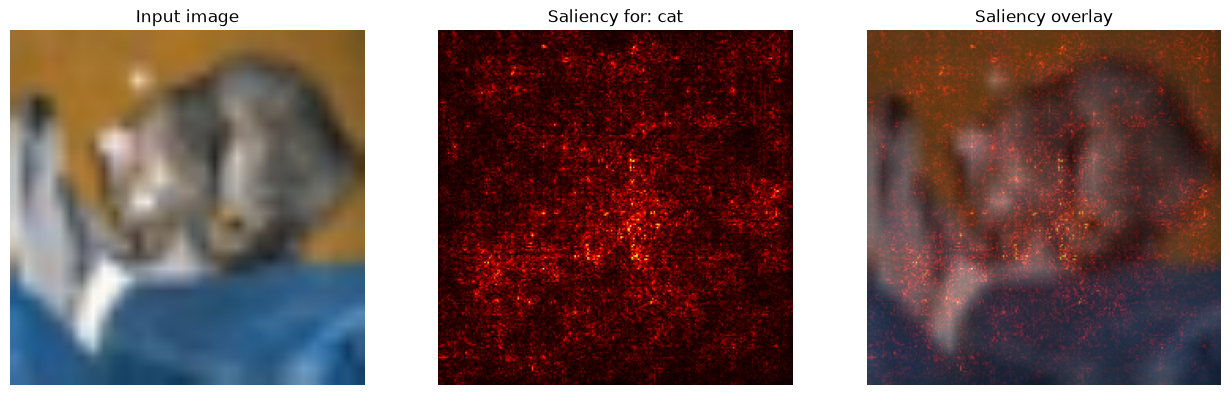

In [5]:
saliency_input = input_batch.detach().clone().requires_grad_(True)
model.zero_grad(set_to_none=True)
saliency_logits = model(saliency_input)
saliency_class = int(saliency_logits.argmax(dim=1).item())
saliency_logits[0, saliency_class].backward()
saliency = saliency_input.grad.detach().abs().amax(dim=1)[0].cpu().numpy()
saliency = saliency / (saliency.max() + 1e-8)
saliency_label = class_labels[saliency_class]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(display_image)
axes[0].set_title("Input image")
axes[1].imshow(saliency, cmap="hot")
axes[1].set_title(f"Saliency for: {saliency_label}")
axes[2].imshow(display_image)
axes[2].imshow(saliency, cmap="hot", alpha=0.5)
axes[2].set_title("Saliency overlay")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()

## 6. Grad-CAM introduction

Grad-CAM uses gradients of a target class score flowing into a convolutional layer to weight that layer's activation maps. The weighted, nonnegative sum is resized into a coarse heatmap.

We use ResNet-18's final convolutional stage (layer4). If NB 10's checkpoint is available, the target class is the CIFAR-10 model prediction. Otherwise, the fallback ImageNet model uses its predicted ImageNet category.

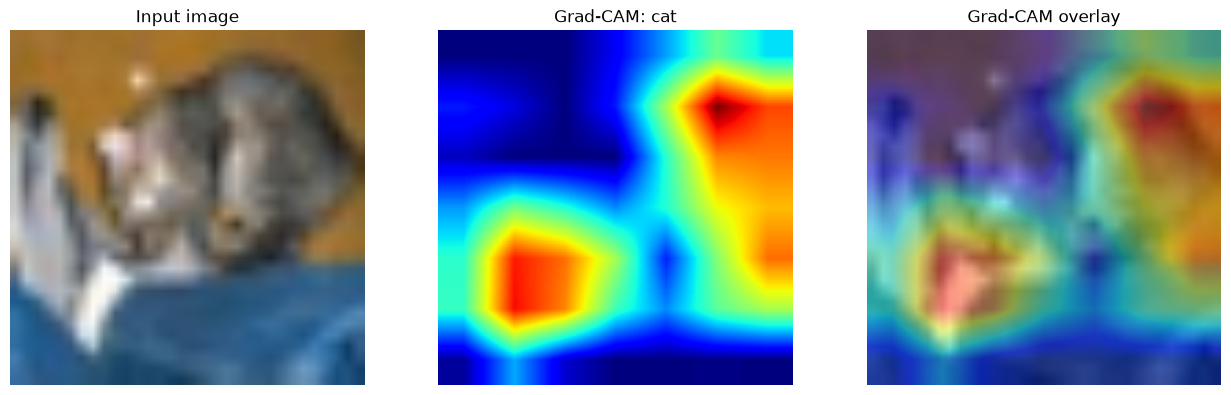

In [6]:
target_layer = model.layer4
gradcam_state = {}
def capture_gradcam(_module, _inputs, output):
    gradcam_state["activations"] = output
    output.register_hook(lambda gradient: gradcam_state.__setitem__("gradients", gradient))
gradcam_handle = target_layer.register_forward_hook(capture_gradcam)
model.zero_grad(set_to_none=True)
gradcam_logits = model(input_batch)
gradcam_class = int(gradcam_logits.argmax(dim=1).item())
gradcam_logits[0, gradcam_class].backward()
gradcam_handle.remove()
activations = gradcam_state["activations"].detach()
gradients = gradcam_state["gradients"].detach()
channel_weights = gradients.mean(dim=(2, 3), keepdim=True)
gradcam_map = torch.relu((channel_weights * activations).sum(dim=1, keepdim=True))
gradcam_map = torch.nn.functional.interpolate(
    gradcam_map, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False
)[0, 0].cpu().numpy()
gradcam_map = gradcam_map / (gradcam_map.max() + 1e-8)
gradcam_label = class_labels[gradcam_class]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(display_image)
axes[0].set_title("Input image")
axes[1].imshow(gradcam_map, cmap="jet")
axes[1].set_title(f"Grad-CAM: {gradcam_label}")
axes[2].imshow(display_image)
axes[2].imshow(gradcam_map, cmap="jet", alpha=0.45)
axes[2].set_title("Grad-CAM overlay")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()

## 7. What to look for—and limitations

- Do highlighted regions overlap the object, or mostly the background?
- Are early-stage maps detailed while deeper-stage maps are spatially coarser?
- Do saliency and Grad-CAM emphasize similar or different regions?
- Does the prediction appear to rely on a spurious cue?

Grad-CAM highlights coarse class-associated regions; it does not provide exact object boundaries. Saliency can be noisy. Direct filter visualization is clearest for early layers and harder to interpret for deeper learned channels. Always inspect several examples and treat these plots as diagnostic evidence, not a complete explanation.

## 8. Summary

This notebook used one image from the local CIFAR-10 test set to visualize:

- first-layer convolution filters
- intermediate feature maps at early, middle, and deep stages
- input saliency for the predicted class
- Grad-CAM at ResNet-18's final convolutional stage

Remember the general progression: **early layers → edges/simple patterns; middle layers → textures/shapes; deeper layers → higher-level patterns.** The visualizations reveal responses of a particular trained model to particular inputs; they do not prove how every CNN represents images.